## Market

---

Market data describes the commercial side of the electricity system.

These datasets are useful for understanding how electricity is traded and how
prices and commercial positions are formed.

### Typical units

- Price: `EUR/MWh`
- Power/exchange: `MW`

### Typical applications

- Electricity price forecasting
- Market analysis
- Market coupling analysis
- Bidding strategies
- Cross-border trading analysis

---

# Config

---

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
plt.style.use("ggplot")

import os
from dotenv import load_dotenv

from entsoe import EntsoePandasClient

load_dotenv()

# ENTSOE Token
entsoe_token = os.getenv("ENTSOE_API_TOKEN")

# ENTSOE Client
entsoe_client = EntsoePandasClient(api_key=entsoe_token)

# Settings

---

In [2]:
# Location
country_capital = "Madrid"
country_code = "ES"

# Period
tz = f"Europe/{country_capital}"

now = pd.Timestamp.now(tz=tz)
today = now.normalize()

yesterday = today - pd.Timedelta(days=1)
last_week = today - pd.Timedelta(days=7)
last_month = today - pd.DateOffset(months=1)

tomorrow = today + pd.Timedelta(days=1)
day_after_tomorrow = today + pd.Timedelta(days=2)
next_week = today + pd.Timedelta(days=7)
next_month = today + pd.DateOffset(months=1)

# Mappings
---

In [3]:
process_types = {
    'A01': 'Day ahead',
    'A02': 'Intra day incremental',
    'A16': 'Realised',
    'A18': 'Intraday total',
    'A31': 'Week ahead',
    'A32': 'Month ahead',
    'A33': 'Year ahead',
    'A39': 'Synchronisation process',
    'A40': 'Intraday process',
    'A46': 'Replacement reserve',
    'A47': 'Manual frequency restoration reserve',
    'A51': 'Automatic frequency restoration reserve',
    'A52': 'Frequency containment reserve',
    'A56': 'Frequency restoration reserve',
    'A60': 'Scheduled activation mFRR',
    'A61': 'Direct activation mFRR',
    'A67': 'Central Selection aFRR',
    'A68': 'Local Selection aFRR'
}

# EDA
---

###################################################################################
# .query_day_ahead_prices
(country_code, start=start, end=end) -> pd.Series

* Day-ahead market clearing price (€/MWh).

In [4]:
day_ahead_prices = entsoe_client.query_day_ahead_prices(
    country_code=country_code,
    start=last_month,
    end=day_after_tomorrow)

In [5]:
day_ahead_prices.info()

<class 'pandas.Series'>
DatetimeIndex: 3168 entries, 2026-08-03 00:00:00+02:00 to 2026-09-04 23:45:00+02:00
Series name: None
Non-Null Count  Dtype  
--------------  -----  
3168 non-null   float64
dtypes: float64(1)
memory usage: 49.5 KB


In [6]:
day_ahead_prices.head()

2026-08-03 00:00:00+02:00    182.92
2026-08-03 00:15:00+02:00    182.40
2026-08-03 00:30:00+02:00    181.92
2026-08-03 00:45:00+02:00    180.92
2026-08-03 01:00:00+02:00    179.92
dtype: float64

In [7]:
day_ahead_prices.tail()

2026-09-04 22:45:00+02:00    217.45
2026-09-04 23:00:00+02:00    217.50
2026-09-04 23:15:00+02:00    217.00
2026-09-04 23:30:00+02:00    215.00
2026-09-04 23:45:00+02:00    214.00
dtype: float64

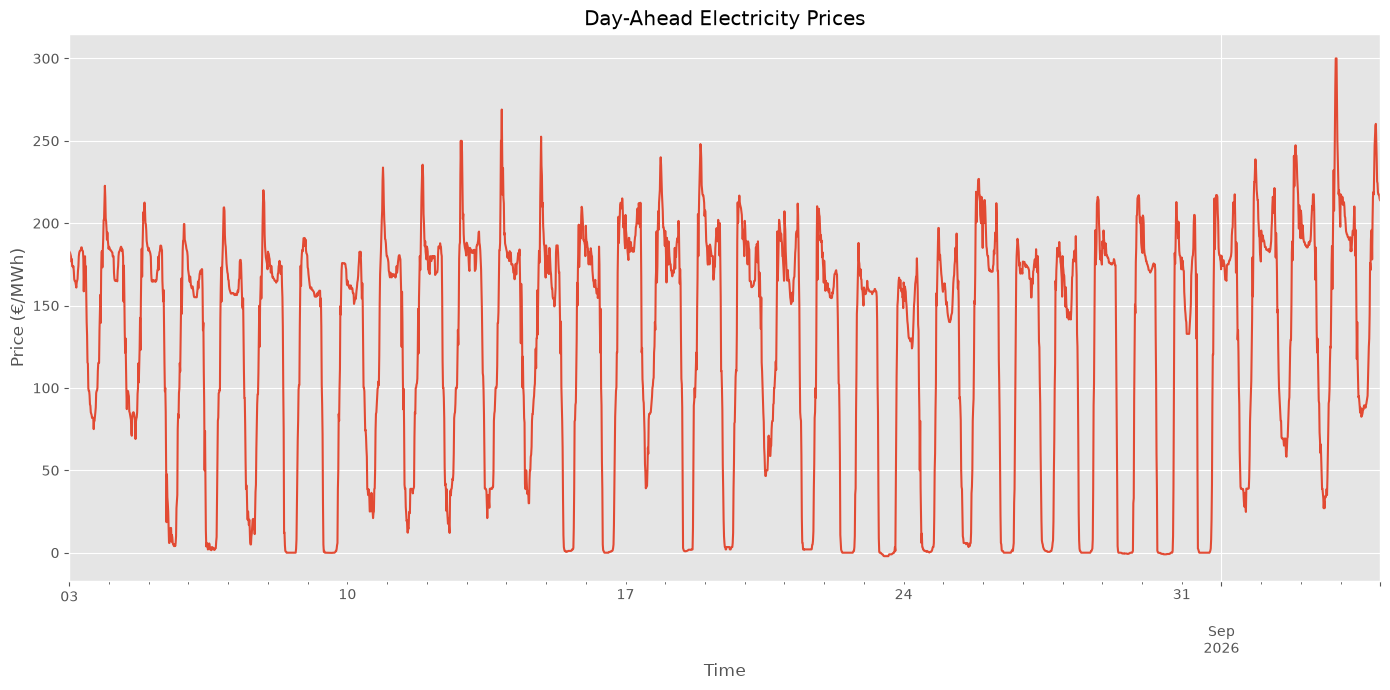

In [8]:
fig, ax = plt.subplots(figsize=(14, 7))

day_ahead_prices.plot(ax=ax)

ax.set_title("Day-Ahead Electricity Prices")
ax.set_xlabel("Time")
ax.set_ylabel("Price (€/MWh)")

fig.tight_layout()
plt.show()

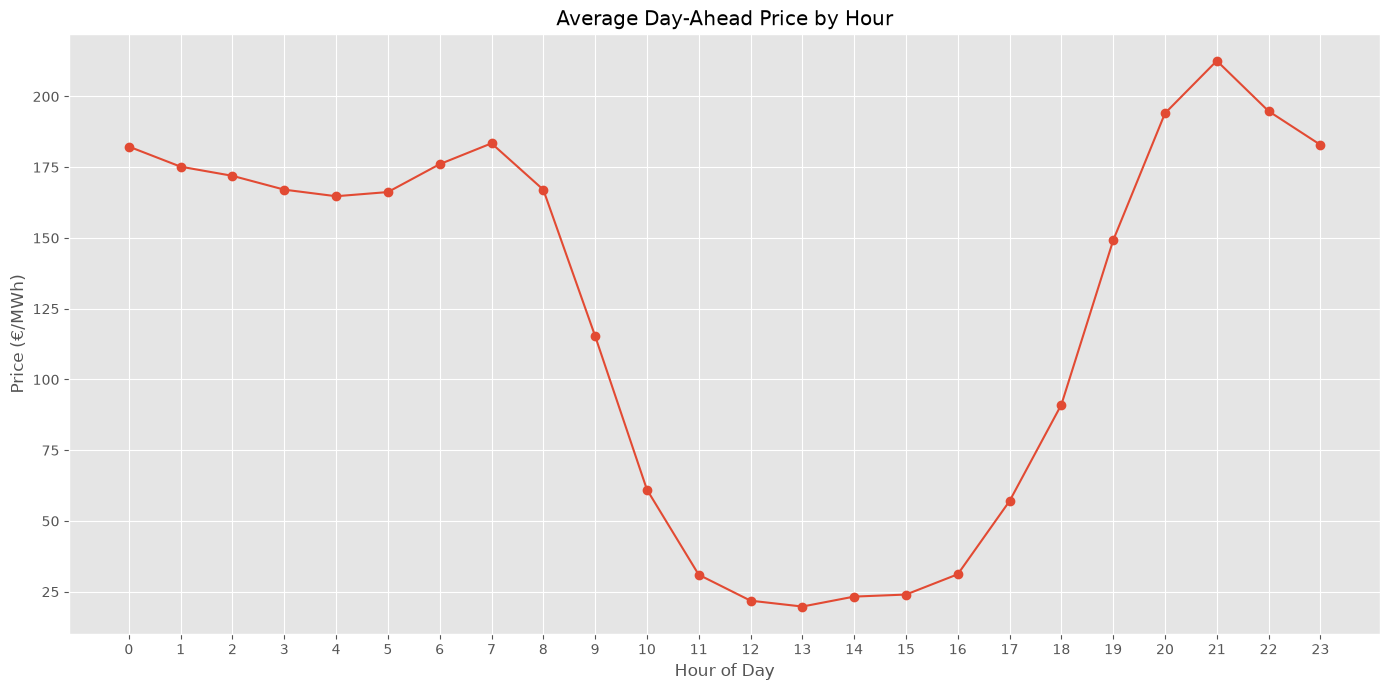

In [9]:
fig, ax = plt.subplots(figsize=(14, 7))

day_ahead_prices.groupby(day_ahead_prices.index.hour).mean().plot(
    ax=ax,
    marker="o"
)

ax.set_title("Average Day-Ahead Price by Hour")
ax.set_xlabel("Hour of Day")
ax.set_ylabel("Price (€/MWh)")
ax.set_xticks(range(24))

fig.tight_layout()
plt.show()

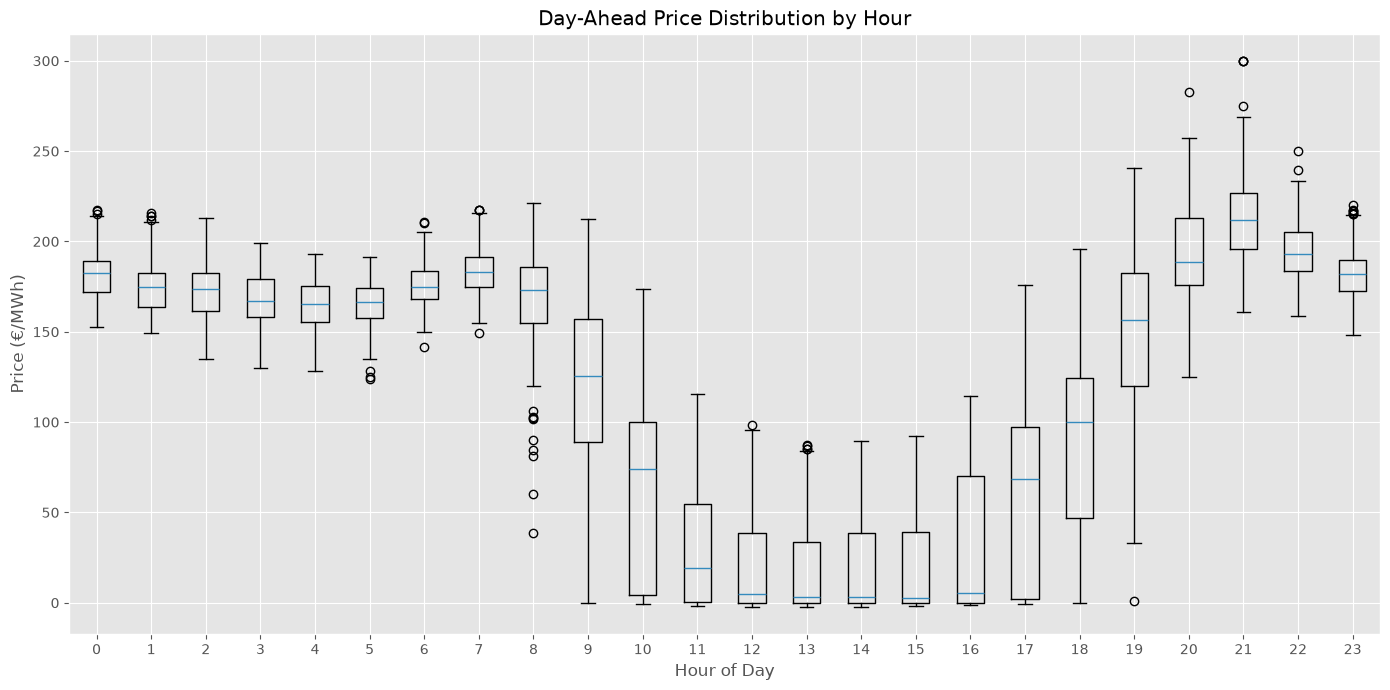

In [10]:
prices_by_hour = [
    day_ahead_prices[day_ahead_prices.index.hour == hour].values
    for hour in range(24)
]

fig, ax = plt.subplots(figsize=(14, 7))

ax.boxplot(prices_by_hour)

ax.set_title("Day-Ahead Price Distribution by Hour")
ax.set_xlabel("Hour of Day")
ax.set_ylabel("Price (€/MWh)")
ax.set_xticks(range(1, 25), range(24))

fig.tight_layout()
plt.show()

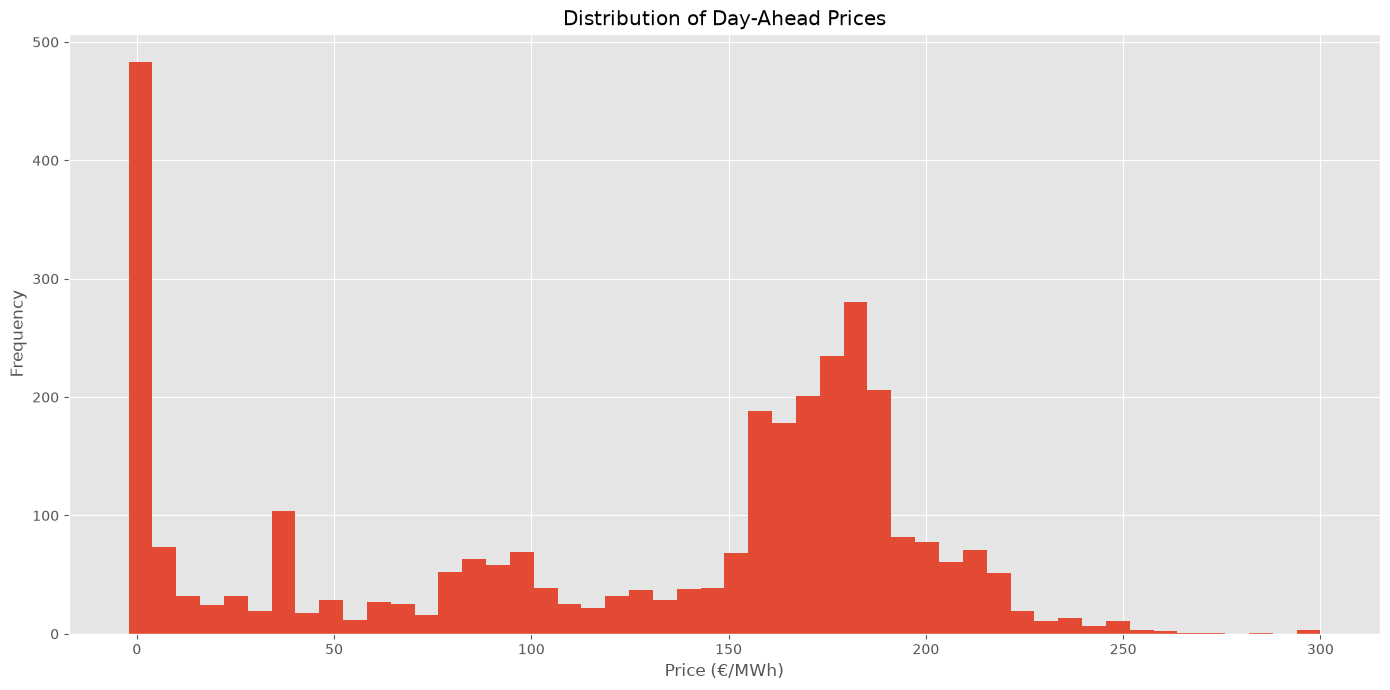

In [11]:
fig, ax = plt.subplots(figsize=(14, 7))

day_ahead_prices.plot.hist(
    bins=50,
    ax=ax
)

ax.set_title("Distribution of Day-Ahead Prices")
ax.set_xlabel("Price (€/MWh)")
ax.set_ylabel("Frequency")

fig.tight_layout()
plt.show()

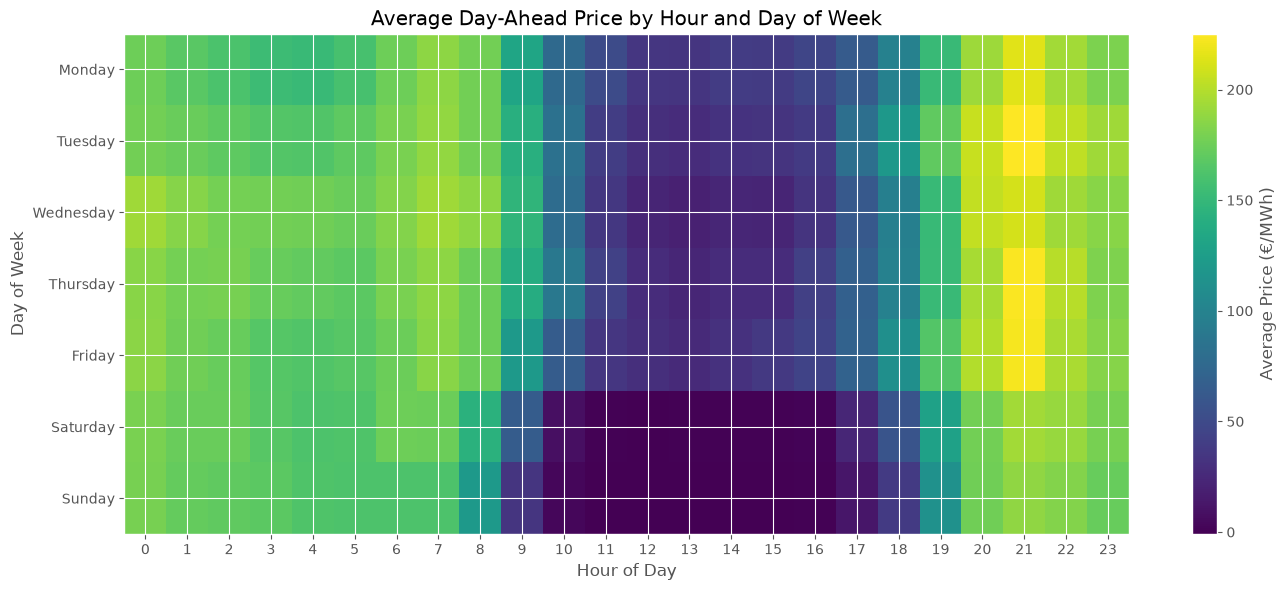

In [12]:
prices = day_ahead_prices.copy()
prices.index = pd.to_datetime(prices.index)

# Average price for each hour and day of week
heatmap_data = (
    prices
    .groupby([
        prices.index.day_name(),
        prices.index.hour
    ])
    .mean()
    .unstack()
)

# Put days in the correct order
day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday",
]

heatmap_data = heatmap_data.reindex(day_order)


fig, ax = plt.subplots(figsize=(14, 6))

image = ax.imshow(
    heatmap_data,
    aspect="auto",
    interpolation="nearest"
)

# Axis labels
ax.set_xlabel("Hour of Day")
ax.set_ylabel("Day of Week")
ax.set_title("Average Day-Ahead Price by Hour and Day of Week")

# Ticks
ax.set_xticks(range(24))
ax.set_xticklabels(range(24))

ax.set_yticks(range(7))
ax.set_yticklabels(day_order)

# Colorbar
colorbar = fig.colorbar(image, ax=ax)
colorbar.set_label("Average Price (€/MWh)")

fig.tight_layout()
plt.show()

###################################################################################
# .query_aggregated_bids
(country_code, start=start, end=end, process_type) -> pd.Series

* Aggregated market bids (MW).

In [13]:
# ### processType allowed values: A51, A46, A47, A60, A61, A67, A68' ###

# for process_type in process_types:
#     try:
#         df = entsoe_client.query_aggregated_bids(
#                 country_code=country_code,
#                 start=last_week,
#                 end=tomorrow,
#                 process_type=process_type
#         )
#         print(process_type, df.shape)
#     except Exception as e:
#         print(process_type, repr(e))

In [14]:
allowed_process_types_agg_bids = {
    # 'A46': 'Replacement reserve',
    'A47': 'Manual frequency restoration reserve',
    'A51': 'Automatic frequency restoration reserve',
    # 'A60': 'Scheduled activation mFRR',
    # 'A61': 'Direct activation mFRR',
    'A67': 'Central Selection aFRR',
    # 'A68': 'Local Selection aFRR'
}

In [15]:
aggregated_bids_aFRR = entsoe_client.query_aggregated_bids(
    country_code=country_code,
    start=last_week,
    end=tomorrow,
    process_type="A51")

In [16]:
aggregated_bids_aFRR.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 507 entries, 2026-08-27 00:00:00+02:00 to 2026-09-01 06:30:00+02:00
Freq: 15min
Data columns (total 4 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   (Down, 1, Activated)  0 non-null      object
 1   (Down, 1, Offered)    453 non-null    object
 2   (Up, 2, Activated)    0 non-null      object
 3   (Up, 2, Offered)      445 non-null    object
dtypes: object(4)
memory usage: 19.8+ KB


In [17]:
aggregated_bids_aFRR.head()

direction                      Down                Up        
mrid                              1                 2        
unit                      Activated Offered Activated Offered
2026-08-27 00:00:00+02:00       NaN  1078.0       NaN  1108.0
2026-08-27 00:15:00+02:00       NaN  1086.0       NaN  1118.0
2026-08-27 00:30:00+02:00       NaN  1098.0       NaN  1109.0
2026-08-27 00:45:00+02:00       NaN  1033.0       NaN  1011.0
2026-08-27 01:00:00+02:00       NaN  1028.0       NaN  1003.0

In [18]:
aggregated_bids_aFRR.tail()

direction                      Down                Up        
mrid                              1                 2        
unit                      Activated Offered Activated Offered
2026-09-01 05:30:00+02:00       NaN     NaN       NaN     NaN
2026-09-01 05:45:00+02:00       NaN     NaN       NaN     NaN
2026-09-01 06:00:00+02:00       NaN     NaN       NaN     NaN
2026-09-01 06:15:00+02:00       NaN     NaN       NaN     NaN
2026-09-01 06:30:00+02:00       NaN     NaN       NaN     NaN

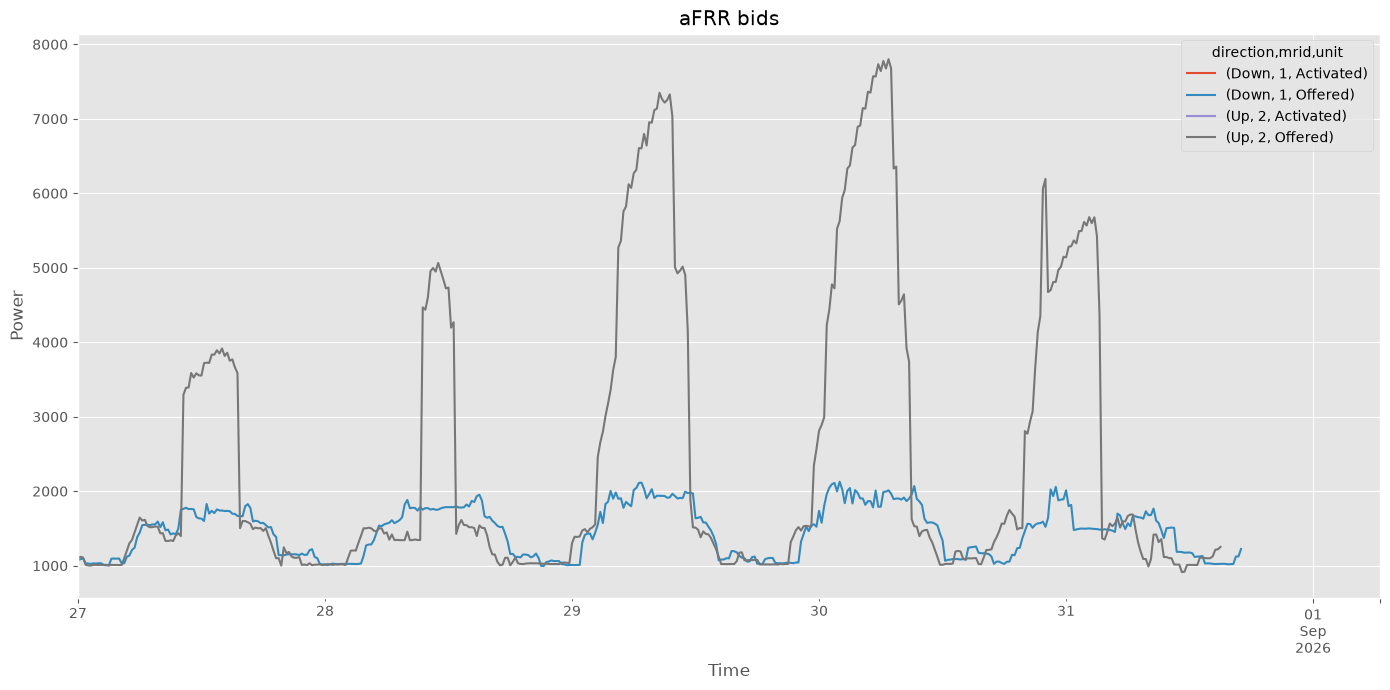

In [19]:
fig, ax = plt.subplots(figsize=(14, 7))

aggregated_bids_aFRR.plot(ax=ax)

ax.set_title("aFRR bids")
ax.set_xlabel("Time")
ax.set_ylabel("Power")

fig.tight_layout()
plt.show()

In [20]:
aggregated_bids_mFRR = entsoe_client.query_aggregated_bids(
    country_code=country_code,
    start=last_week,
    end=tomorrow,
    process_type="A47")

In [21]:
aggregated_bids_mFRR.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 508 entries, 2026-08-27 00:00:00+02:00 to 2026-09-01 06:45:00+02:00
Freq: 15min
Data columns (total 4 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   (Down, 1, Activated)  0 non-null      object
 1   (Down, 1, Offered)    508 non-null    object
 2   (Up, 2, Activated)    0 non-null      object
 3   (Up, 2, Offered)      508 non-null    object
dtypes: object(4)
memory usage: 19.8+ KB


In [22]:
aggregated_bids_mFRR.head()

direction                      Down                Up        
mrid                              1                 2        
unit                      Activated Offered Activated Offered
2026-08-27 00:00:00+02:00       NaN  7630.0       NaN  5645.0
2026-08-27 00:15:00+02:00       NaN  7593.0       NaN  5934.0
2026-08-27 00:30:00+02:00       NaN  7550.0       NaN  5825.0
2026-08-27 00:45:00+02:00       NaN  7025.0       NaN  6318.0
2026-08-27 01:00:00+02:00       NaN  6940.0       NaN  5794.0

In [23]:
aggregated_bids_mFRR.tail()

direction                      Down                Up        
mrid                              1                 2        
unit                      Activated Offered Activated Offered
2026-09-01 05:45:00+02:00       NaN  4796.0       NaN  5651.0
2026-09-01 06:00:00+02:00       NaN  5390.0       NaN  5394.0
2026-09-01 06:15:00+02:00       NaN  5459.0       NaN  5356.0
2026-09-01 06:30:00+02:00       NaN  5069.0       NaN  5805.0
2026-09-01 06:45:00+02:00       NaN  5404.0       NaN  6252.0

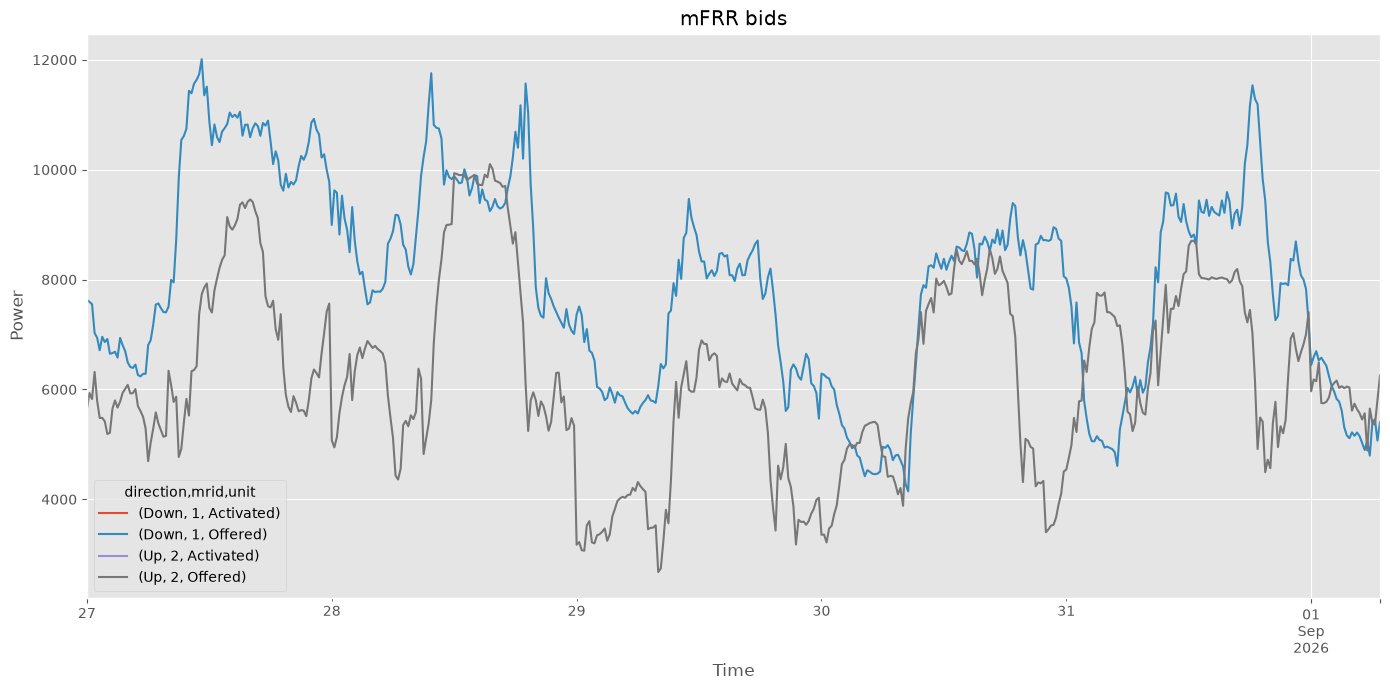

In [24]:
fig, ax = plt.subplots(figsize=(14, 7))

aggregated_bids_mFRR.plot(ax=ax)

ax.set_title("mFRR bids")
ax.set_xlabel("Time")
ax.set_ylabel("Power")

fig.tight_layout()
plt.show()

In [25]:
aggregated_bids_central_selection_aFRR = entsoe_client.query_aggregated_bids(
    country_code=country_code,
    start=last_week,
    end=tomorrow,
    process_type="A67")

In [26]:
aggregated_bids_central_selection_aFRR.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 748 entries, 2026-08-27 00:00:00+02:00 to 2026-09-03 18:45:00+02:00
Freq: 15min
Data columns (total 4 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   (Down, 1, Activated)  743 non-null    object
 1   (Down, 1, Offered)    743 non-null    object
 2   (Up, 2, Activated)    739 non-null    object
 3   (Up, 2, Offered)      739 non-null    object
dtypes: object(4)
memory usage: 29.2+ KB


In [27]:
aggregated_bids_central_selection_aFRR.head()

direction                      Down                 Up         
mrid                              1                  2         
unit                      Activated  Offered Activated  Offered
2026-08-27 00:00:00+02:00   13.0079  1078.04    5.8153  1108.04
2026-08-27 00:15:00+02:00    7.6319   1086.0   30.9452   1118.0
2026-08-27 00:30:00+02:00   15.1596  1086.05   16.8005  1117.96
2026-08-27 00:45:00+02:00    8.4516  1097.71   23.1808  1108.56
2026-08-27 01:00:00+02:00   10.2374  1032.98   136.319  1010.96

In [28]:
aggregated_bids_central_selection_aFRR.tail()

direction                      Down                Up        
mrid                              1                 2        
unit                      Activated Offered Activated Offered
2026-09-03 17:45:00+02:00       NaN     NaN       NaN     NaN
2026-09-03 18:00:00+02:00       NaN     NaN       NaN     NaN
2026-09-03 18:15:00+02:00       NaN     NaN       NaN     NaN
2026-09-03 18:30:00+02:00       NaN     NaN       NaN     NaN
2026-09-03 18:45:00+02:00       NaN     NaN       NaN     NaN

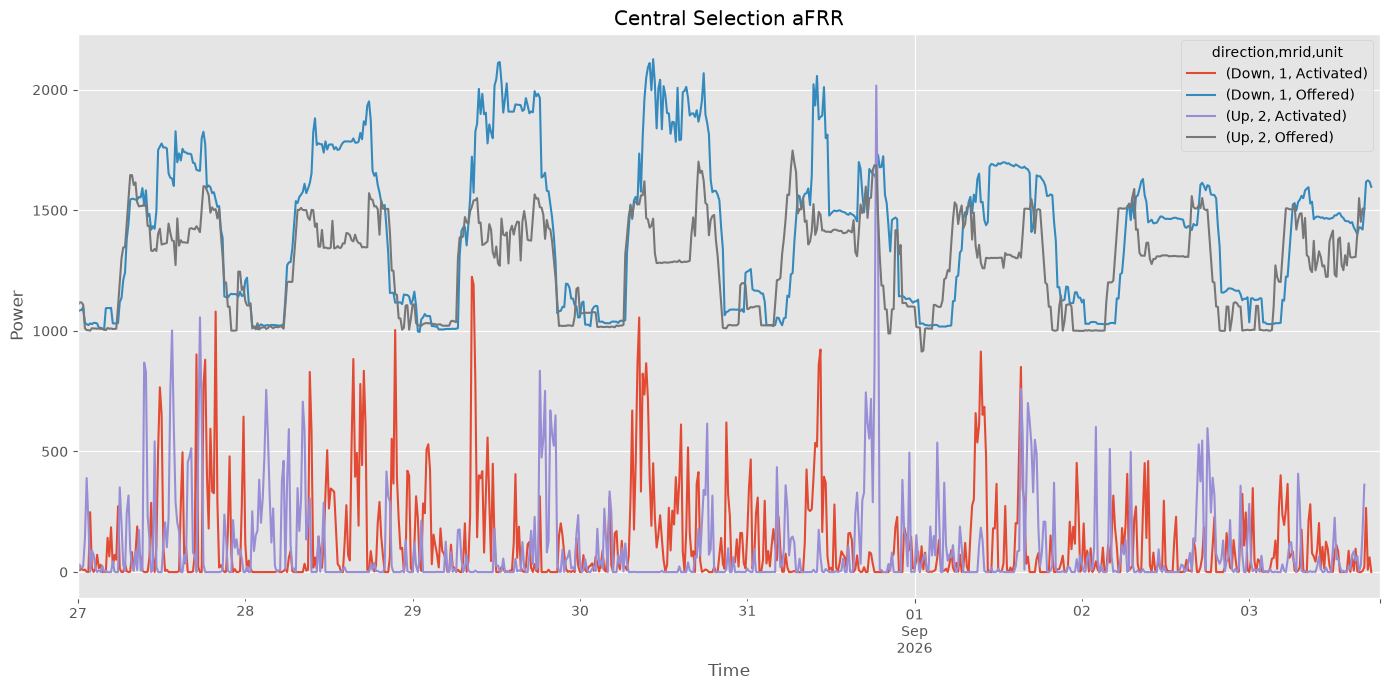

In [29]:
fig, ax = plt.subplots(figsize=(14, 7))

aggregated_bids_central_selection_aFRR.plot(ax=ax)

ax.set_title("Central Selection aFRR")
ax.set_xlabel("Time")
ax.set_ylabel("Power")

fig.tight_layout()
plt.show()

###################################################################################
# .query_net_position
(country_code, start=start, end=end, dayahead=True) -> pd.Series

- as defined by CACM article 2(5): “the netted sum of electricity exports and imports for each market time unit for a bidding zone” expressed in MW
- the day-ahead implicit net position consists of the sum of all commercial exchanges across all bidding zone borders from implicit day-ahead allocations.
- the total implicit net position consists of the sum of all commercial exchanges across all bidding zone borders from implicit day-ahead allocations as well as all implicit intraday allocations (including continuous allocations), as a single publication of values for the entire day.
- he explicit allocations, TSO-TSO schedules (due to redispatch and countertrade) and balancing schedules are not included.
- primary owner of the data: net positions are calculated by Market Operator (PXs)
- data provider: net positions (TCA, TSO or task delegated to third party (E.g. Market Operator,)

Source: ENTSOE MoP V3R5

* This is a market-scheduled position, not necessarily the physical flow actually observed on the transmission network.

In [30]:
net_positions = entsoe_client.query_net_position(
    country_code=country_code,
    start=last_week,
    end=day_after_tomorrow,
    dayahead=True)

In [31]:
net_positions.info()

<class 'pandas.Series'>
DatetimeIndex: 864 entries, 2026-08-27 00:00:00+02:00 to 2026-09-04 23:45:00+02:00
Series name: None
Non-Null Count  Dtype  
--------------  -----  
864 non-null    float64
dtypes: float64(1)
memory usage: 13.5 KB


In [32]:
net_positions.head()

2026-08-27 00:00:00+02:00   -1296.8
2026-08-27 00:15:00+02:00   -1277.2
2026-08-27 00:30:00+02:00   -1060.4
2026-08-27 00:45:00+02:00   -1457.4
2026-08-27 01:00:00+02:00   -1524.0
dtype: float64

In [33]:
net_positions.tail()

2026-09-04 22:45:00+02:00   -1168.9
2026-09-04 23:00:00+02:00   -1250.5
2026-09-04 23:15:00+02:00   -1391.7
2026-09-04 23:30:00+02:00   -1498.7
2026-09-04 23:45:00+02:00   -1473.1
dtype: float64

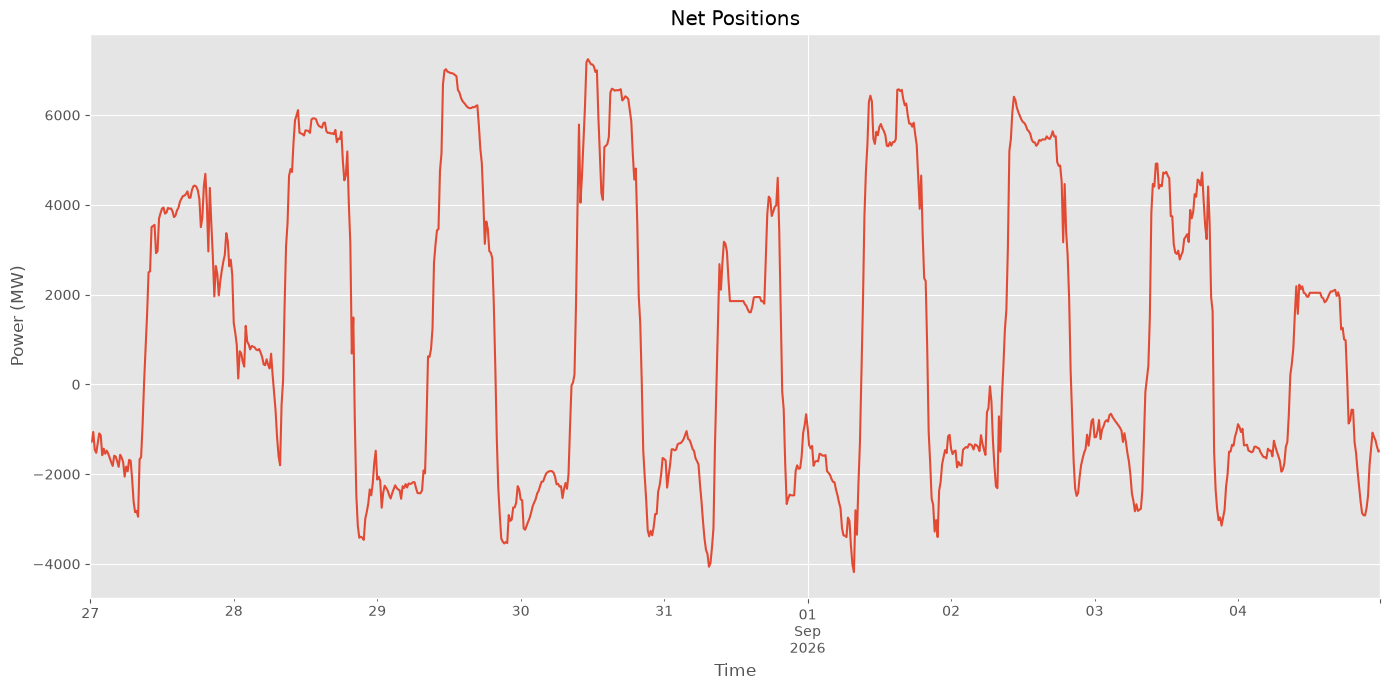

In [34]:
fig, ax = plt.subplots(figsize=(14, 7))

net_positions.plot(ax=ax)

ax.set_title("Net Positions")
ax.set_xlabel("Time")
ax.set_ylabel("Power (MW)")

fig.tight_layout()
plt.show()

###################################################################################
# .query_scheduled_exchanges
(country_code_from, country_code_to, start=start, end=end, dayahead=False) -> pd.Series

* Scheduled commercial cross-border electricity exchanges.

In [35]:
scheduled_exchanges = entsoe_client.query_scheduled_exchanges(
    country_code_from="ES",
    country_code_to="FR",
    start=last_week,
    end=day_after_tomorrow,
    dayahead=False)

In [36]:
scheduled_exchanges.info()

<class 'pandas.Series'>
DatetimeIndex: 864 entries, 2026-08-27 00:00:00+02:00 to 2026-09-04 23:45:00+02:00
Freq: 15min
Series name: None
Non-Null Count  Dtype  
--------------  -----  
864 non-null    float64
dtypes: float64(1)
memory usage: 13.5 KB


In [37]:
scheduled_exchanges.head()

2026-08-27 00:00:00+02:00    96.6
2026-08-27 00:15:00+02:00     4.5
2026-08-27 00:30:00+02:00     0.0
2026-08-27 00:45:00+02:00     0.0
2026-08-27 01:00:00+02:00     2.3
Freq: 15min, dtype: float64

In [38]:
scheduled_exchanges.tail()

2026-09-04 22:45:00+02:00    0.0
2026-09-04 23:00:00+02:00    0.0
2026-09-04 23:15:00+02:00    0.0
2026-09-04 23:30:00+02:00    0.0
2026-09-04 23:45:00+02:00    0.0
Freq: 15min, dtype: float64

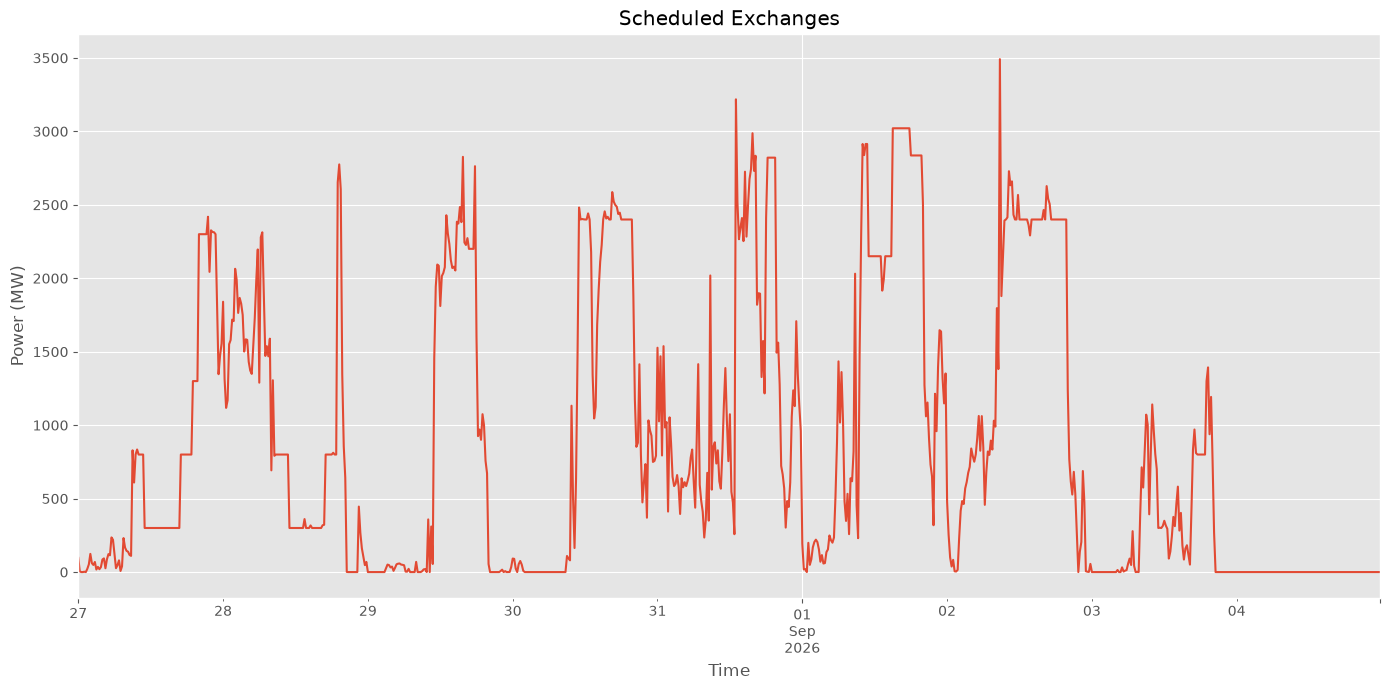

In [39]:
fig, ax = plt.subplots(figsize=(14, 7))

scheduled_exchanges.plot(ax=ax)

ax.set_title("Scheduled Exchanges")
ax.set_xlabel("Time")
ax.set_ylabel("Power (MW)")

fig.tight_layout()
plt.show()

###################################################################################
# .query_offered_capacity
(country_code_from, country_code_to, contract_marketagreement_type, start=start, end=end, implicit=True) -> pd.Series

In [40]:
offered_capacity = entsoe_client.query_offered_capacity(
    country_code_from="ES",
    country_code_to="FR",
    contract_marketagreement_type="A01",
    start=last_week,
    end=today,
    implicit=True)

In [41]:
offered_capacity.info()

<class 'pandas.Series'>
DatetimeIndex: 672 entries, 2026-08-27 00:00:00+02:00 to 2026-09-02 23:45:00+02:00
Freq: 15min
Series name: None
Non-Null Count  Dtype  
--------------  -----  
672 non-null    float64
dtypes: float64(1)
memory usage: 10.5 KB


In [42]:
offered_capacity.head()

2026-08-27 00:00:00+02:00    2300.0
2026-08-27 00:15:00+02:00    2300.0
2026-08-27 00:30:00+02:00    2300.0
2026-08-27 00:45:00+02:00    2300.0
2026-08-27 01:00:00+02:00    2300.0
Freq: 15min, dtype: float64

In [43]:
offered_capacity.tail()

2026-09-02 22:45:00+02:00    2350.0
2026-09-02 23:00:00+02:00    2350.0
2026-09-02 23:15:00+02:00    2350.0
2026-09-02 23:30:00+02:00    2350.0
2026-09-02 23:45:00+02:00    2350.0
Freq: 15min, dtype: float64

<Axes: >

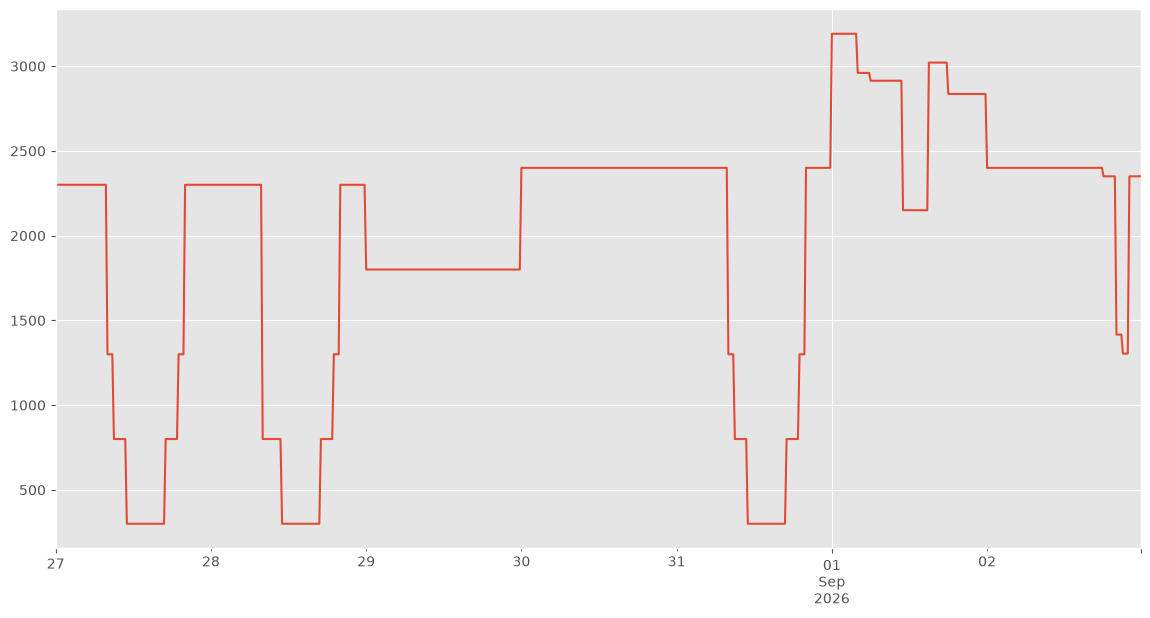

In [44]:
plt.figure(figsize=(14, 7))
offered_capacity.plot()

###################################################################################
# .query_intraday_offered_capacity
(country_code_from, country_code_to, start=start, end=end, implicit=True) -> pd.Series

In [45]:
intraday_offered_capacity = entsoe_client.query_intraday_offered_capacity(
    country_code_from="ES",
    country_code_to="FR",
    start=last_week,
    end=today,
    implicit=True)

In [46]:
intraday_offered_capacity.info()

<class 'pandas.Series'>
DatetimeIndex: 672 entries, 2026-08-27 00:00:00+02:00 to 2026-09-02 23:45:00+02:00
Freq: 15min
Series name: None
Non-Null Count  Dtype  
--------------  -----  
672 non-null    float64
dtypes: float64(1)
memory usage: 10.5 KB


In [47]:
intraday_offered_capacity.head()

2026-08-27 00:00:00+02:00    4503.4
2026-08-27 00:15:00+02:00    4595.5
2026-08-27 00:30:00+02:00    4600.0
2026-08-27 00:45:00+02:00    4600.0
2026-08-27 01:00:00+02:00    4599.0
Freq: 15min, dtype: float64

In [48]:
intraday_offered_capacity.tail()

2026-09-02 22:45:00+02:00    4778.8
2026-09-02 23:00:00+02:00    4975.0
2026-09-02 23:15:00+02:00    4975.0
2026-09-02 23:30:00+02:00    4975.0
2026-09-02 23:45:00+02:00    4919.3
Freq: 15min, dtype: float64

<Axes: >

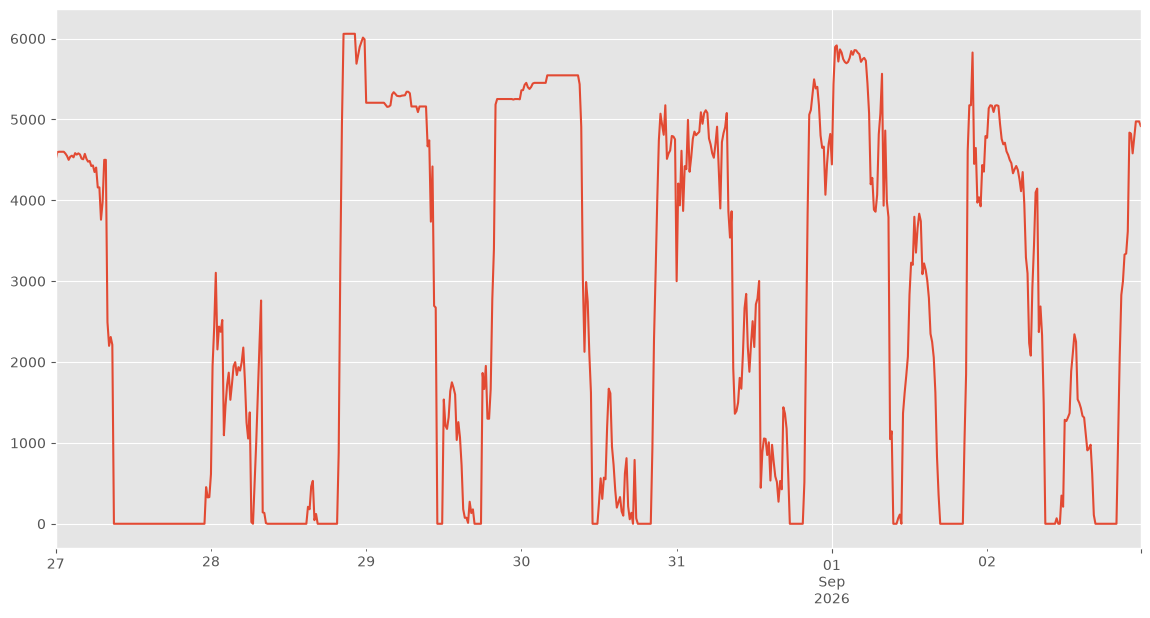

In [49]:
plt.figure(figsize=(14, 7))
intraday_offered_capacity.plot()